In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path


n = 0 (31 x 51):
    cells count (from gmsh) = 1794 elements
    mdot = -1419.751878

n = 1 (61 x 101):
    cells count (from gmsh) = 6454 elements
    mdot = -1400.518595

n = 2 (121 x 201):
    cells count (from gmsh) = 24772 elements
    mdot = -1395.915375
    
n = 3 (241 x 401):
    cells count (from gmsh) = 97414 elements
    mdot = -1395.260684

         

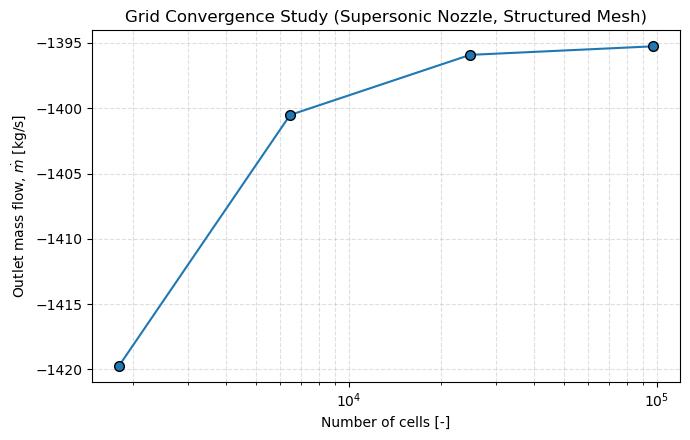

In [3]:
# Structured mesh convergence data
cell_count = [1794, 6454, 24772, 97414]
mdot = [-1419.751878, -1400.518595, -1395.915375, -1395.260684]

plt.figure(figsize=(7, 4.5))
plt.plot(
    cell_count, mdot,
    linestyle='-',
    marker='o',
    markersize=7,
    markerfacecolor='tab:blue',   # filled symbols
    markeredgecolor='black',
    color='tab:blue'
)

plt.xscale('log', base=10)
plt.xlabel('Number of cells [-]')
plt.ylabel(r'Outlet mass flow, $\dot{m}$ [kg/s]')
plt.title('Grid Convergence Study (Supersonic Nozzle, Structured Mesh)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()

# Save to Lab2\Images\convergence_study.pdf
save_path = r'Outputs\convergence_study.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')

plt.show()


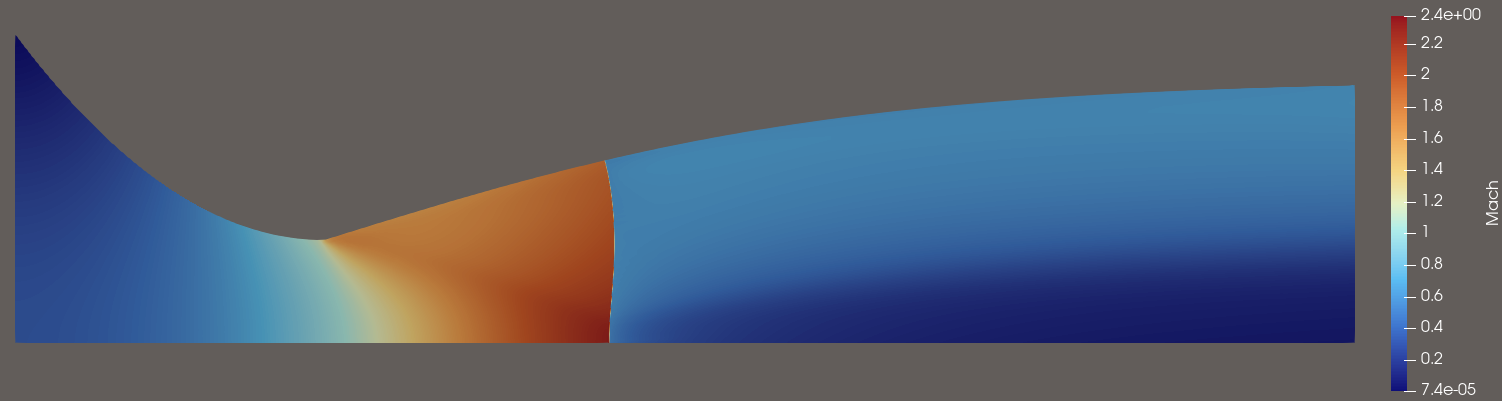

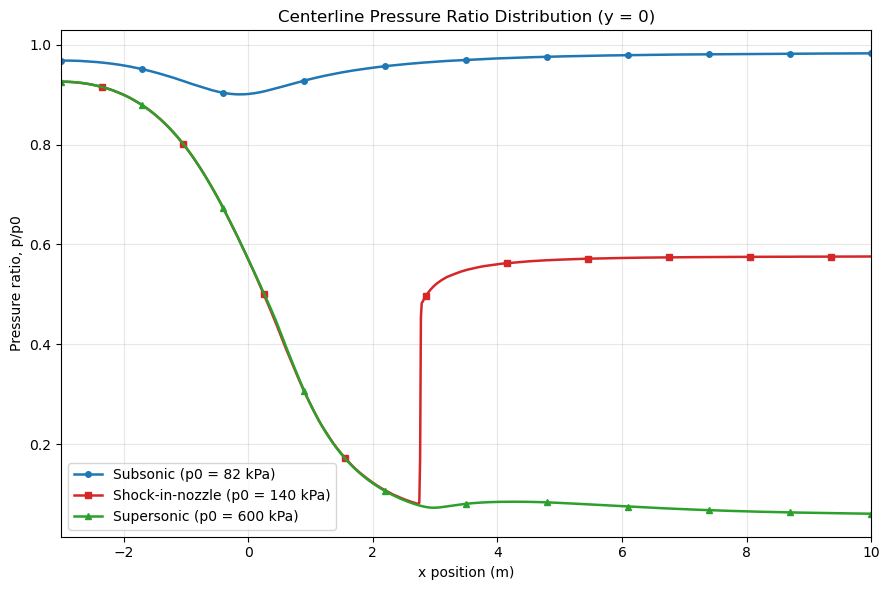

Saved: \\ad.uillinois.edu\engr-ews\kovalov2\AE462\AE462-git\Lab2\Outputs\centerline pressure ratio distribution.pdf
Reference exit pressure ratio p_exit/p0:
Subsonic (p0 = 82 kPa): 0.9829
Shock-in-nozzle (p0 = 140 kPa): 0.5757
Supersonic (p0 = 600 kPa): 0.1343


In [4]:
# ---- File setup ----
base = Path("Outputs")
files = {
    "Subsonic (p0 = 82 kPa)": "subsonic.csv",
    "Shock-in-nozzle (p0 = 140 kPa)": "shock.csv",
    "Supersonic (p0 = 600 kPa)": "supersonic n=3.csv",
}

# Inlet stagnation pressures (Pa)
p0_map = {
    "Subsonic (p0 = 82 kPa)": 82e3,
    "Shock-in-nozzle (p0 = 140 kPa)": 140e3,
    "Supersonic (p0 = 600 kPa)": 600e3,
}

# ---- Plot setup ----
plt.figure(figsize=(9, 6))
styles = {
    # markevery=(start, step) offsets marker placement to reduce overlap
    "Subsonic (p0 = 82 kPa)": dict(color="tab:blue", marker="o", markevery=(0, 100), lw=1.8, ms=4),
    "Shock-in-nozzle (p0 = 140 kPa)": dict(color="tab:red", marker="s", markevery=(50, 100), lw=1.8, ms=4),
    "Supersonic (p0 = 600 kPa)": dict(color="tab:green", marker="^", markevery=(0, 100), lw=1.8, ms=4),
}

# ---- Read and plot ----
for label, fname in files.items():
    df = pd.read_csv(base / fname)
    df = df.sort_values("Points:0")
    df = df[df["Points:0"].between(-3.0, 10.0)]
    df["p_over_p0"] = df["Pressure"] / p0_map[label]
    plt.plot(df["Points:0"], df["p_over_p0"], label=label, **styles[label])

# ---- Final formatting ----
plt.xlabel("x position (m)")
plt.ylabel("Pressure ratio, p/p0")
plt.title("Centerline Pressure Ratio Distribution (y = 0)")
plt.xlim(-3, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save PDF
out_dir = Path("Outputs")
out_dir.mkdir(parents=True, exist_ok=True)
pdf_path = out_dir / "centerline pressure ratio distribution.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {pdf_path.resolve()}")

# Reference values
p_exit = 80.6e3
print("Reference exit pressure ratio p_exit/p0:")
for k, v in p0_map.items():
    print(f"{k}: {p_exit/v:.4f}")


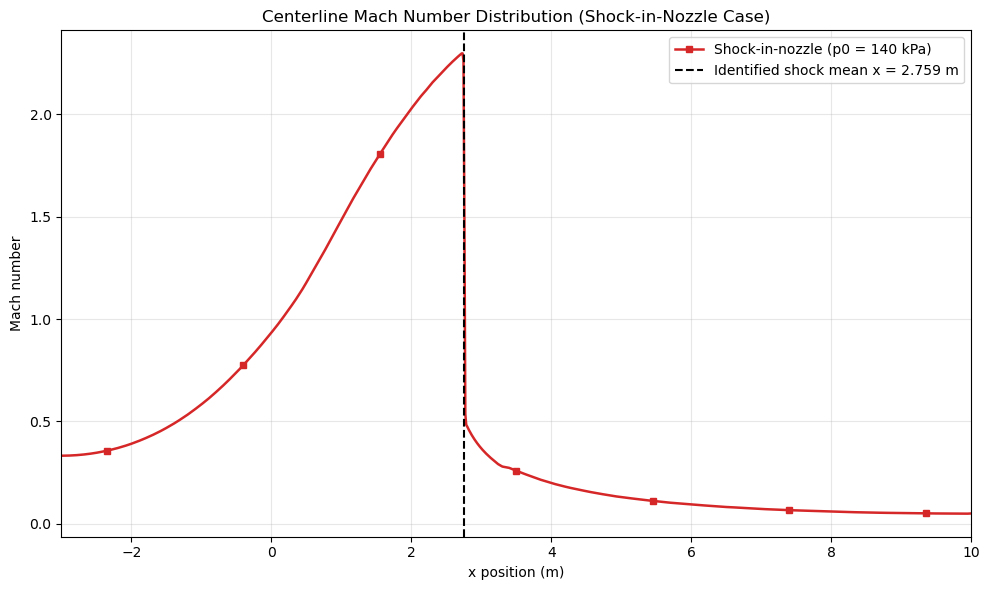

Saved: \\ad.uillinois.edu\engr-ews\kovalov2\AE462\AE462-git\Lab2\Outputs\shock mach distribution.pdf
Mean identified shock position: x = 2.7590 m


In [9]:
# Shock case only
base = Path("Outputs")
fname = "shock.csv"
label = "Shock-in-nozzle (p0 = 140 kPa)"

df = pd.read_csv(base / fname)
df = df.sort_values("Points:0")
df = df[df["Points:0"].between(-3.0, 10.0)]

x = df["Points:0"].to_numpy()
M = df["Mach"].to_numpy()

# Identify shock location from steepest Mach drop
dMdx = np.gradient(M, x)
i_min = np.argmin(dMdx)

# Mean x around steepest-drop neighborhood
k = 4
i0 = max(i_min - k, 0)
i1 = min(i_min + k + 1, len(x))
shock_x_mean = x[i0:i1].mean()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(
    x, M,
    color="tab:red", marker="s", markevery=(50, 150), lw=1.8, ms=4,
    label=label
)
plt.axvline(
    shock_x_mean, color="k", ls="--", lw=1.5,
    label=f"Identified shock mean x = {shock_x_mean:.3f} m"
)

plt.xlabel("x position (m)")
plt.ylabel("Mach number")
plt.title("Centerline Mach Number Distribution (Shock-in-Nozzle Case)")
plt.xlim(-3, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save PDF
out_dir = Path("Outputs")
out_dir.mkdir(parents=True, exist_ok=True)
pdf_path = out_dir / "shock mach distribution.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()
print(f"Saved: {pdf_path.resolve()}")
print(f"Mean identified shock position: x = {shock_x_mean:.4f} m")
